In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

In [2]:
# ============================================
# SHL Grammar Scoring Engine - Dataset Setup
# ============================================

import os
import pandas as pd
import numpy as np

# Base paths
BASE_PATH = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
TEST_CSV = os.path.join(BASE_PATH, "test.csv")
SAMPLE_SUBMISSION = os.path.join(BASE_PATH, "sample_submission.csv")

TRAIN_AUDIO_DIR = os.path.join(BASE_PATH, "train")
TEST_AUDIO_DIR = os.path.join(BASE_PATH, "test")

# Load CSV files
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nSample submission columns:")
print(sample_submission_df.columns.tolist())

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)

Train columns:
['filename', 'label']

Test columns:
['filename', 'label']

Sample submission columns:
['filename', 'label']


In [3]:
# ============================================
# Exploratory Data Analysis - Grammar Labels
# ============================================

print("Missing values:")
print(train_df.isnull().sum())

print("\nDuplicate rows:")
print(train_df.duplicated().sum())

print("\nLabel statistics:")
print(train_df["label"].describe())

print("\nUnique grammar scores:")
print(sorted(train_df["label"].unique()))

print("\nGrammar score frequency:")
print(train_df["label"].value_counts().sort_index())

Missing values:
filename    0
label       0
dtype: int64

Duplicate rows:
0

Label statistics:
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64

Unique grammar scores:
[np.float64(0.0), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]

Grammar score frequency:
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


In [4]:
# ============================================
# Check Test vs Sample Submission Filenames
# ============================================

test_files = set(test_df["filename"])
sample_files = set(sample_submission_df["filename"])

print("Test files:", len(test_files))
print("Sample submission files:", len(sample_files))

missing_from_sample = sorted(test_files - sample_files)
extra_in_sample = sorted(sample_files - test_files)

print("\nTest files missing from sample submission:", len(missing_from_sample))
print(missing_from_sample)

print("\nExtra files in sample submission:", len(extra_in_sample))
print(extra_in_sample)

print("\nDuplicate filenames in test:", test_df["filename"].duplicated().sum())
print("Duplicate filenames in sample:", sample_submission_df["filename"].duplicated().sum())

Test files: 216
Sample submission files: 204

Test files missing from sample submission: 191
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav', 'audio_102.wav', 'audio_103.wav', 'audio_104.wav', 'audio_105.wav', 'audio_106.wav', 'audio_107.wav', 'audio_109.wav', 'audio_11.wav', 'audio_110.wav', 'audio_111.wav', 'audio_112.wav', 'audio_113.wav', 'audio_114.wav', 'audio_115.wav', 'audio_116.wav', 'audio_118.wav', 'audio_119.wav', 'audio_12.wav', 'audio_120.wav', 'audio_121.wav', 'audio_122.wav', 'audio_123.wav', 'audio_124.wav', 'audio_125.wav', 'audio_126.wav', 'audio_127.wav', 'audio_129.wav', 'audio_131.wav', 'audio_132.wav', 'audio_133.wav', 'audio_134.wav', 'audio_135.wav', 'audio_136.wav', 'audio_137.wav', 'audio_138.wav', 'audio_139.wav', 'audio_140.wav', 'audio_141.wav', 'audio_142.wav', 'audio_143.wav', 'audio_144.wav', 'audio_145.wav', 'audio_146.wav', 'audio_147.wav', 'audio_148.wav', 'audio_149.wav', 'audio_15.wav', 'audio_150.wav', 'audio_151.wa

In [5]:
# ============================================
# AUDIO FILE INSPECTION
# ============================================

import os
import soundfile as sf
import pandas as pd
import numpy as np

BASE_PATH = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

TRAIN_AUDIO_PATH = os.path.join(BASE_PATH, "train")
TEST_AUDIO_PATH = os.path.join(BASE_PATH, "test")


def inspect_audio(file_path):
    try:
        info = sf.info(file_path)

        return {
            "filename": os.path.basename(file_path),
            "sample_rate": info.samplerate,
            "channels": info.channels,
            "frames": info.frames,
            "duration_sec": info.duration
        }

    except Exception as e:
        return {
            "filename": os.path.basename(file_path),
            "sample_rate": None,
            "channels": None,
            "frames": None,
            "duration_sec": None
        }


# Get audio files
train_audio_files = [
    os.path.join(TRAIN_AUDIO_PATH, f)
    for f in os.listdir(TRAIN_AUDIO_PATH)
    if f.lower().endswith(".wav")
]

test_audio_files = [
    os.path.join(TEST_AUDIO_PATH, f)
    for f in os.listdir(TEST_AUDIO_PATH)
    if f.lower().endswith(".wav")
]


print("Train audio files:", len(train_audio_files))
print("Test audio files:", len(test_audio_files))


# Inspect all audio files
train_audio_info = pd.DataFrame(
    [inspect_audio(f) for f in train_audio_files]
)

test_audio_info = pd.DataFrame(
    [inspect_audio(f) for f in test_audio_files]
)


print("\n===== TRAIN AUDIO INFO =====")
display(train_audio_info.head())

print("\n===== TEST AUDIO INFO =====")
display(test_audio_info.head())


print("\n===== TRAIN SAMPLE RATE =====")
print(train_audio_info["sample_rate"].value_counts())

print("\n===== TRAIN CHANNELS =====")
print(train_audio_info["channels"].value_counts())

print("\n===== TRAIN DURATION =====")
print(train_audio_info["duration_sec"].describe())


print("\n===== TEST SAMPLE RATE =====")
print(test_audio_info["sample_rate"].value_counts())

print("\n===== TEST CHANNELS =====")
print(test_audio_info["channels"].value_counts())

print("\n===== TEST DURATION =====")
print(test_audio_info["duration_sec"].describe())

Train audio files: 769
Test audio files: 216

===== TRAIN AUDIO INFO =====


,filename,sample_rate,channels,frames,duration_sec
0,audio_49.wav,16000,1,730560,45.660000
1,audio_663.wav,16000,1,961195,60.074688
2,audio_5059.wav,16000,1,960171,60.010688
3,audio_90.wav,16000,1,628800,39.300000
4,audio_581.wav,16000,1,961195,60.074688



===== TEST AUDIO INFO =====


,filename,sample_rate,channels,frames,duration_sec
0,audio_49.wav,16000,1,961195,60.074688
1,audio_90.wav,16000,1,719896,44.993500
2,audio_77.wav,16000,1,961195,60.074688
3,audio_66.wav,16000,1,961195,60.074688
4,audio_54.wav,16000,1,961195,60.074688



===== TRAIN SAMPLE RATE =====
sample_rate
16000    769
Name: count, dtype: int64

===== TRAIN CHANNELS =====
channels
1    769
Name: count, dtype: int64

===== TRAIN DURATION =====
count    769.000000
mean      55.781067
std        7.908964
min       20.060000
25%       54.186687
50%       60.074688
75%       60.074688
max       61.040000
Name: duration_sec, dtype: float64

===== TEST SAMPLE RATE =====
sample_rate
16000    216
Name: count, dtype: int64

===== TEST CHANNELS =====
channels
1    216
Name: count, dtype: int64

===== TEST DURATION =====
count    216.000000
mean      48.755341
std        8.181578
min        6.480000
25%       45.055000
50%       45.060000
75%       60.010688
max       61.034687
Name: duration_sec, dtype: float64


File: audio_192.wav
Sample Rate: 16000
Duration: 60.508375 seconds
Number of Samples: 968134


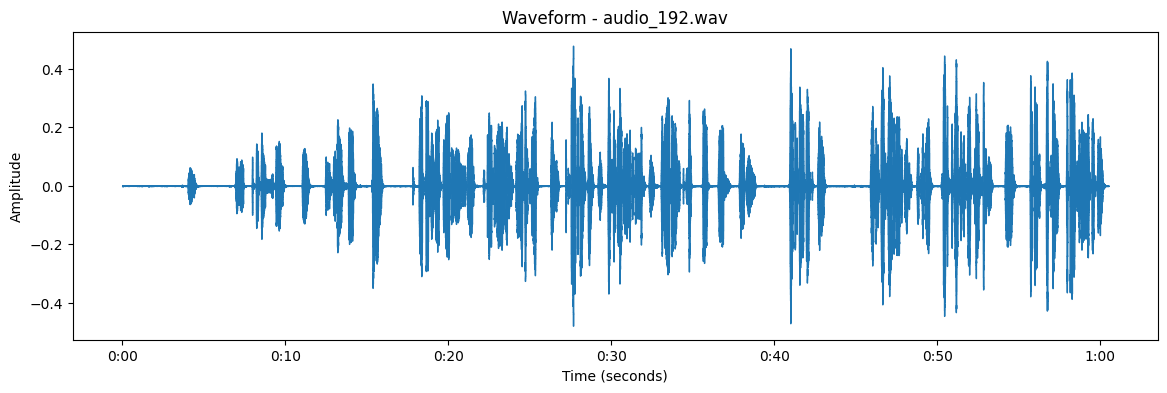

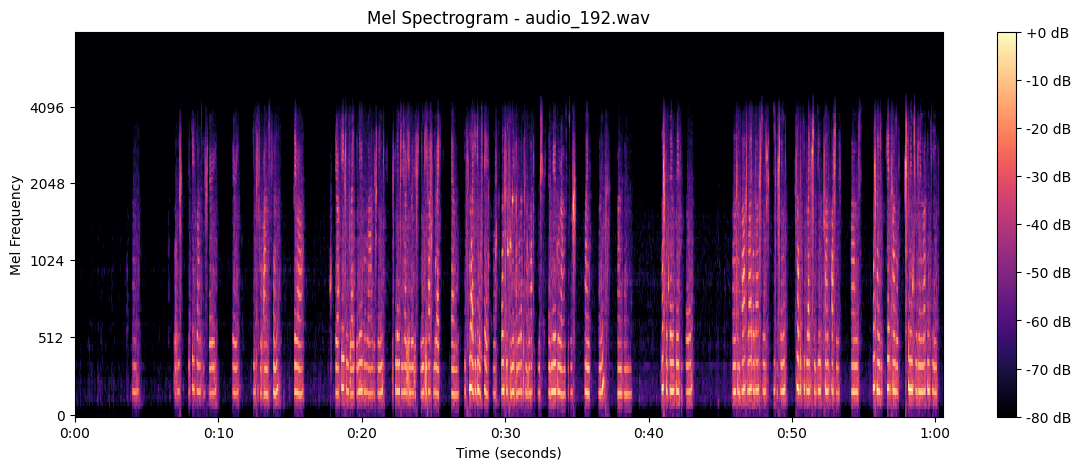

In [6]:
# ============================================
# STEP 4: AUDIO VISUALIZATION
# Waveform + Mel Spectrogram
# ============================================

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Select one training audio file
sample_file = train_df["filename"].iloc[0]

audio_path = os.path.join(TRAIN_AUDIO_PATH, sample_file)

# Load audio
y, sr = librosa.load(audio_path, sr=None)

print("File:", sample_file)
print("Sample Rate:", sr)
print("Duration:", len(y) / sr, "seconds")
print("Number of Samples:", len(y))


# ============================================
# 1. WAVEFORM
# ============================================

plt.figure(figsize=(14, 4))

librosa.display.waveshow(y, sr=sr)

plt.title(f"Waveform - {sample_file}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


# ============================================
# 2. MEL SPECTROGRAM
# ============================================

mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128,
    fmax=sr // 2
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel Spectrogram - {sample_file}")
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")
plt.show()

MFCC shape: (13, 1891)

Mean MFCC features:
[-403.8359     103.57634    -14.213533    16.673616     7.04855
   -4.9996395    5.885733    -9.268934    -8.681059    -6.1113496
  -11.947043    -8.226156    -6.238205 ]


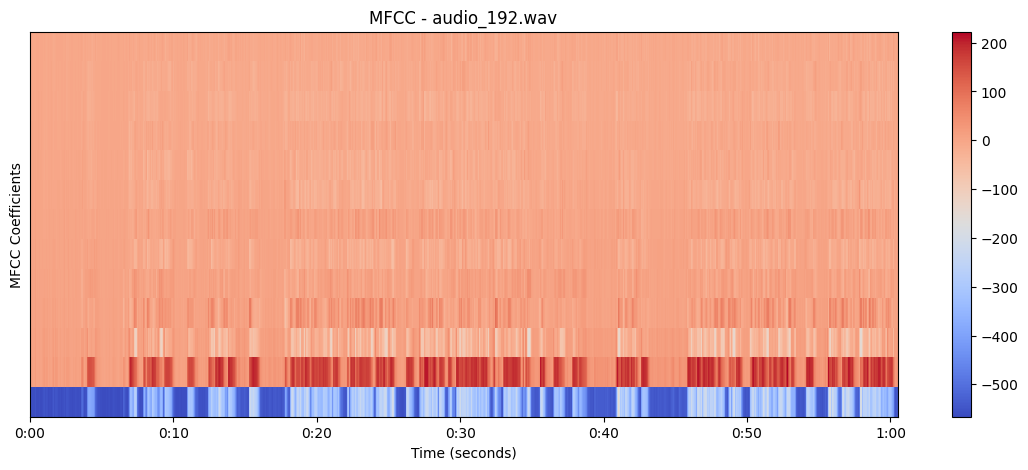

In [7]:
# ============================================
# STEP 5: MFCC FEATURE EXTRACTION
# ============================================

# Extract MFCC features
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

print("MFCC shape:", mfcc.shape)

# Mean MFCC values across time
mfcc_mean = np.mean(mfcc, axis=1)

print("\nMean MFCC features:")
print(mfcc_mean)


# ============================================
# VISUALIZE MFCC
# ============================================

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()
plt.title(f"MFCC - {sample_file}")
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficients")

plt.show()

In [8]:
# ============================================
# STEP 6: AUDIO FEATURE EXTRACTION FUNCTION
# ============================================

def extract_audio_features(file_path):
    """
    Extract numerical audio features from a WAV file.
    """

    # Load audio
    audio, sr = librosa.load(file_path, sr=None)

    # -------------------------------
    # MFCC
    # -------------------------------
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    # -------------------------------
    # Spectral features
    # -------------------------------
    spectral_centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=sr
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=audio,
        sr=sr
    )

    # -------------------------------
    # Time-domain features
    # -------------------------------
    zero_crossing_rate = librosa.feature.zero_crossing_rate(
        audio
    )

    rms = librosa.feature.rms(
        y=audio
    )

    # -------------------------------
    # Combine features
    # -------------------------------
    features = {}

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = mfcc_mean[i]
        features[f"mfcc_{i+1}_std"] = mfcc_std[i]

    features["spectral_centroid_mean"] = np.mean(spectral_centroid)
    features["spectral_bandwidth_mean"] = np.mean(spectral_bandwidth)
    features["spectral_rolloff_mean"] = np.mean(spectral_rolloff)
    features["zero_crossing_rate_mean"] = np.mean(zero_crossing_rate)
    features["rms_mean"] = np.mean(rms)

    return features


# Test on one audio file
test_features = extract_audio_features(audio_path)

print("Number of extracted features:", len(test_features))
print("\nExtracted features:")
print(test_features)

Number of extracted features: 31

Extracted features:
{'mfcc_1_mean': np.float32(-403.8359), 'mfcc_1_std': np.float32(121.62919), 'mfcc_2_mean': np.float32(103.57634), 'mfcc_2_std': np.float32(68.03565), 'mfcc_3_mean': np.float32(-14.213533), 'mfcc_3_std': np.float32(37.100353), 'mfcc_4_mean': np.float32(16.673616), 'mfcc_4_std': np.float32(21.843693), 'mfcc_5_mean': np.float32(7.04855), 'mfcc_5_std': np.float32(11.192187), 'mfcc_6_mean': np.float32(-4.9996395), 'mfcc_6_std': np.float32(14.073897), 'mfcc_7_mean': np.float32(5.885733), 'mfcc_7_std': np.float32(10.086836), 'mfcc_8_mean': np.float32(-9.268934), 'mfcc_8_std': np.float32(11.238889), 'mfcc_9_mean': np.float32(-8.681059), 'mfcc_9_std': np.float32(9.175092), 'mfcc_10_mean': np.float32(-6.1113496), 'mfcc_10_std': np.float32(7.005802), 'mfcc_11_mean': np.float32(-11.947043), 'mfcc_11_std': np.float32(8.755229), 'mfcc_12_mean': np.float32(-8.226156), 'mfcc_12_std': np.float32(6.8834915), 'mfcc_13_mean': np.float32(-6.238205), 'mf

In [9]:
# ============================================
# STEP 7: EXTRACT FEATURES FROM ALL TRAIN AUDIO
# ============================================

feature_rows = []

for i, row in train_df.iterrows():

    filename = row["filename"]
    label = row["label"]

    file_path = os.path.join(TRAIN_AUDIO_PATH, filename)

    try:
        features = extract_audio_features(file_path)

        # Add filename and target label
        features["filename"] = filename
        features["label"] = label

        feature_rows.append(features)

    except Exception as e:
        print(f"Error processing {filename}: {e}")


# Convert list of dictionaries into DataFrame
train_features_df = pd.DataFrame(feature_rows)

print("Feature dataset shape:", train_features_df.shape)

print("\nFirst 5 rows:")
display(train_features_df.head())

print("\nColumns:")
print(train_features_df.columns.tolist())

Feature dataset shape: (769, 33)

First 5 rows:


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_12_std,mfcc_13_mean,mfcc_13_std,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zero_crossing_rate_mean,rms_mean,filename,label
0,-403.835907,121.629189,103.576340,68.035652,-14.213533,37.100353,16.673616,21.843693,7.048550,11.192187,...,6.883492,-6.238205,5.747041,979.478539,916.472067,1770.739688,0.084768,0.031786,audio_192.wav,3.0
1,-287.111023,81.685997,72.087601,56.021065,5.334722,46.173588,24.854349,37.073082,-13.109429,27.177183,...,13.295259,4.751498,13.532232,1813.837012,1502.301143,3277.169030,0.142977,0.068651,audio_436.wav,3.0
2,-324.808197,86.514740,97.828194,59.010967,18.635786,30.665184,5.857049,28.117016,2.258683,18.588797,...,11.855078,-0.866495,11.763124,1652.475254,1500.652559,2941.260650,0.146870,0.054421,audio_447.wav,3.5
3,-489.320648,124.842316,111.792915,53.296013,0.751575,41.733730,33.133247,33.229671,8.309433,21.988724,...,10.599061,-17.710949,11.394984,996.631363,1177.252185,1865.640525,0.059477,0.013778,audio_126.wav,2.0
4,-483.865997,159.520401,51.975899,58.754555,-21.642136,44.306683,31.146597,36.615963,-11.265674,24.949566,...,10.692766,-17.764479,15.302751,2278.144095,1630.415181,4034.356241,0.169988,0.009330,audio_61.wav,2.0



Columns:
['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'zero_crossing_rate_mean', 'rms_mean', 'filename', 'label']


In [10]:
# ============================================
# STEP 8: VALIDATE FEATURE DATASET
# ============================================

print("===== DATASET INFO =====")
print("Shape:", train_features_df.shape)

print("\n===== MISSING VALUES =====")
print(train_features_df.isnull().sum())

print("\n===== DUPLICATE ROWS =====")
print("Duplicates:", train_features_df.duplicated().sum())

print("\n===== FEATURE STATISTICS =====")
display(train_features_df.describe().T)

print("\n===== TARGET LABEL =====")
print(train_features_df["label"].describe())

print("\n===== LABEL DISTRIBUTION =====")
print(train_features_df["label"].value_counts().sort_index())

===== DATASET INFO =====
Shape: (769, 33)

===== MISSING VALUES =====
mfcc_1_mean                0
mfcc_1_std                 0
mfcc_2_mean                0
mfcc_2_std                 0
mfcc_3_mean                0
mfcc_3_std                 0
mfcc_4_mean                0
mfcc_4_std                 0
mfcc_5_mean                0
mfcc_5_std                 0
mfcc_6_mean                0
mfcc_6_std                 0
mfcc_7_mean                0
mfcc_7_std                 0
mfcc_8_mean                0
mfcc_8_std                 0
mfcc_9_mean                0
mfcc_9_std                 0
mfcc_10_mean               0
mfcc_10_std                0
mfcc_11_mean               0
mfcc_11_std                0
mfcc_12_mean               0
mfcc_12_std                0
mfcc_13_mean               0
mfcc_13_std                0
spectral_centroid_mean     0
spectral_bandwidth_mean    0
spectral_rolloff_mean      0
zero_crossing_rate_mean    0
rms_mean                   0
filename                   0
la

,count,mean,std,min,25%,50%,75%,max
mfcc_1_mean,769.0,-334.545441,94.541481,-582.820374,-379.379883,-342.726959,-306.301514,37.444183
mfcc_1_std,769.0,105.292732,36.362286,5.925910,83.554810,111.062309,131.010025,178.864883
mfcc_2_mean,769.0,77.255051,29.660627,-0.368382,60.594414,81.164040,96.903435,141.712692
mfcc_2_std,769.0,53.534588,16.949541,5.336253,44.897354,54.564999,65.443275,95.218025
mfcc_3_mean,769.0,1.742201,16.730719,-59.860832,-7.994817,2.685820,11.408150,52.566563
mfcc_3_std,769.0,33.986374,10.032807,4.147290,28.558558,35.429359,40.717216,57.270378
mfcc_4_mean,769.0,17.814417,12.502704,-19.711576,8.901430,18.342535,25.535332,59.345032
mfcc_4_std,769.0,29.283295,8.055772,3.572634,26.044504,30.426273,34.318157,46.538460
mfcc_5_mean,769.0,-5.245170,11.743911,-48.253670,-13.021101,-5.404285,2.442589,29.434589
mfcc_5_std,769.0,21.077862,6.164344,3.190296,17.800474,21.591829,25.125824,35.610336



===== TARGET LABEL =====
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64

===== LABEL DISTRIBUTION =====
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


===== FEATURE-TARGET CORRELATION =====
mfcc_1_mean               -0.443924
spectral_bandwidth_mean   -0.401057
spectral_rolloff_mean     -0.399859
zero_crossing_rate_mean   -0.373713
spectral_centroid_mean    -0.363943
rms_mean                  -0.335389
mfcc_11_mean              -0.277277
mfcc_7_mean               -0.213993
mfcc_6_mean               -0.182962
mfcc_8_mean               -0.162054
mfcc_13_mean              -0.154632
mfcc_10_mean              -0.125129
mfcc_5_mean               -0.099371
mfcc_9_mean               -0.071526
mfcc_12_mean              -0.055138
mfcc_3_mean                0.012127
mfcc_4_mean                0.199534
mfcc_2_mean                0.259342
mfcc_12_std                0.465906
mfcc_13_std                0.468755
mfcc_10_std                0.492653
mfcc_1_std                 0.523582
mfcc_11_std                0.523792
mfcc_5_std                 0.556557
mfcc_8_std                 0.562689
mfcc_9_std                 0.580482
mfcc_7_std               

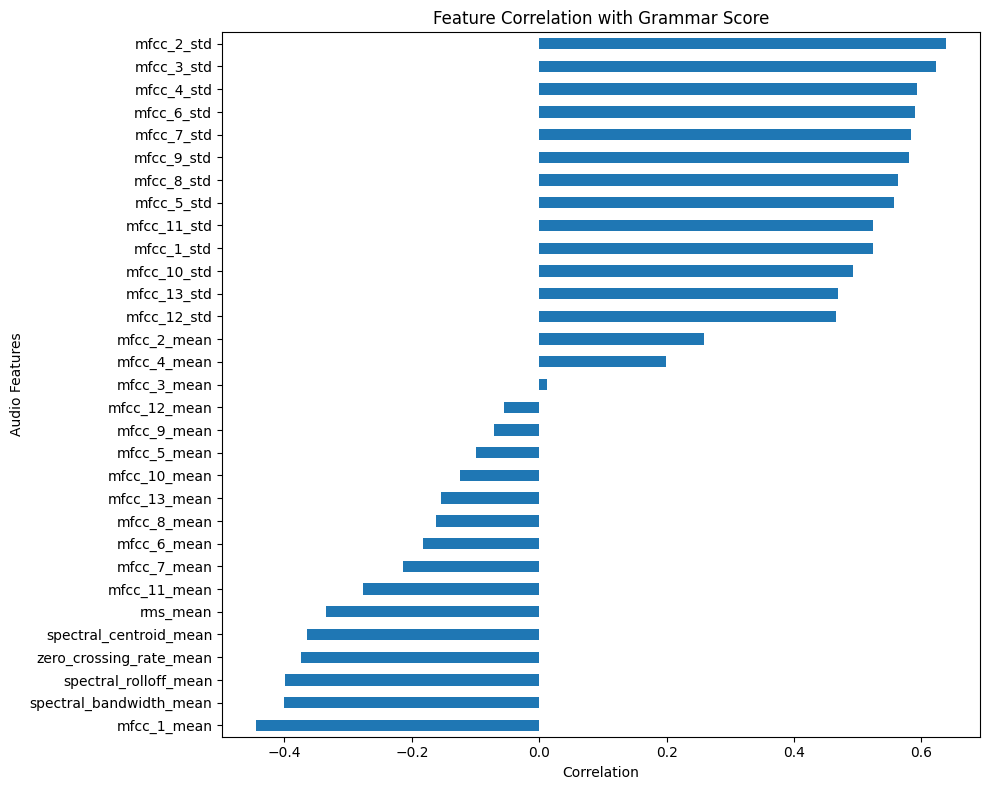

In [11]:
# ============================================
# STEP 9: FEATURE-TARGET CORRELATION ANALYSIS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical features
feature_columns = [
    col for col in train_features_df.columns
    if col not in ["filename", "label"]
]

# Calculate correlation with target
correlations = (
    train_features_df[feature_columns + ["label"]]
    .corr()["label"]
    .drop("label")
    .sort_values()
)

print("===== FEATURE-TARGET CORRELATION =====")
print(correlations)

# Top positive and negative correlations
print("\n===== TOP POSITIVE CORRELATIONS =====")
print(correlations.tail(10).sort_values(ascending=False))

print("\n===== TOP NEGATIVE CORRELATIONS =====")
print(correlations.head(10))

# Plot correlations
plt.figure(figsize=(10, 8))

correlations.plot(kind="barh")

plt.title("Feature Correlation with Grammar Score")
plt.xlabel("Correlation")
plt.ylabel("Audio Features")
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# STEP 10: TRAIN / VALIDATION SPLIT
# ============================================

from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = train_features_df[feature_columns].copy()
y = train_features_df["label"].copy()

# 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("===== TRAIN / VALIDATION SPLIT =====")
print("Original dataset:", X.shape)

print("\nTraining features:", X_train.shape)
print("Validation features:", X_val.shape)

print("\nTraining target:", y_train.shape)
print("Validation target:", y_val.shape)

print("\nTraining score distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation score distribution:")
print(y_val.value_counts().sort_index())

===== TRAIN / VALIDATION SPLIT =====
Original dataset: (769, 31)

Training features: (615, 31)
Validation features: (154, 31)

Training target: (615,)
Validation target: (154,)

Training score distribution:
label
0.0     24
1.0      1
1.5      3
2.0     82
2.5     66
3.0    144
3.5     48
4.0     98
4.5     38
5.0    111
Name: count, dtype: int64

Validation score distribution:
label
0.0    13
2.0    20
2.5    13
3.0    30
3.5    16
4.0    26
4.5    14
5.0    22
Name: count, dtype: int64


In [13]:
# ============================================
# STEP 11: FEATURE SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data using the same scaler
X_val_scaled = scaler.transform(X_val)

print("===== FEATURE SCALING =====")

print("Original X_train shape:", X_train.shape)
print("Scaled X_train shape:", X_train_scaled.shape)

print("\nOriginal X_val shape:", X_val.shape)
print("Scaled X_val shape:", X_val_scaled.shape)

print("\nFirst 5 scaled training samples:")
print(X_train_scaled[:5])

print("\nScaled training mean:")
print(X_train_scaled.mean(axis=0)[:10])

print("\nScaled training standard deviation:")
print(X_train_scaled.std(axis=0)[:10])

===== FEATURE SCALING =====
Original X_train shape: (615, 31)
Scaled X_train shape: (615, 31)

Original X_val shape: (154, 31)
Scaled X_val shape: (154, 31)

First 5 scaled training samples:
[[-1.04662682  1.22457453 -2.43407822  0.21923691  1.87656155 -0.28120099
   0.31994708 -0.21934157 -0.17782024  0.57070121  2.27998713 -0.20878138
  -0.35771009  0.43642066  2.3664935  -0.56793053 -0.25433635  0.73598807
   2.30710641 -0.74605486 -0.21665675  0.1745466   1.6563221   0.17816703
   1.74365306 -0.38785914  2.57502573  1.47178774  2.11337868  1.87927814
  -1.37373103]
 [ 0.55837339 -0.41163461  0.53815758 -0.31808614  0.83727742  0.016604
   0.27863156  0.59533088 -1.26036848  0.78813561 -0.39865703  1.06289355
  -1.3578453   1.48741432 -0.06027126  1.37997928  0.08727729  1.59876672
   0.64200513 -0.3769772  -0.36134368  0.82103568 -0.55587866  1.41301479
   0.25448541  0.43014012 -0.43090337 -0.10100292 -0.39534034 -0.33612038
   1.6385758 ]
 [-0.1770813   0.10929899 -0.2604013   0.

In [14]:
# ============================================
# STEP 12: BASELINE MODEL - LINEAR REGRESSION
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train_scaled, y_train)

# Predictions on validation data
y_pred_linear = linear_model.predict(X_val_scaled)

# Evaluation metrics
mae_linear = mean_absolute_error(y_val, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_val, y_pred_linear))
r2_linear = r2_score(y_val, y_pred_linear)

print("===== LINEAR REGRESSION RESULTS =====")
print(f"MAE  : {mae_linear:.4f}")
print(f"RMSE : {rmse_linear:.4f}")
print(f"R²   : {r2_linear:.4f}")

# Show actual vs predicted
comparison_linear = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": y_pred_linear
})

print("\n===== ACTUAL vs PREDICTED =====")
display(comparison_linear.head(15))

===== LINEAR REGRESSION RESULTS =====
MAE  : 0.6168
RMSE : 0.7672
R²   : 0.6791

===== ACTUAL vs PREDICTED =====


,Actual,Predicted
0,0.0,-0.450662
1,3.0,3.648203
2,3.5,3.817551
3,0.0,0.725746
4,5.0,3.939488
5,2.0,3.001653
6,4.5,3.390864
7,5.0,3.871845
8,5.0,3.945553
9,5.0,4.064833


In [15]:
# ============================================
# STEP 13: RIDGE REGRESSION
# ============================================

from sklearn.linear_model import Ridge

# Create Ridge model
ridge_model = Ridge(alpha=1.0)

# Train
ridge_model.fit(X_train_scaled, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_val_scaled)

# Evaluation
mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
r2_ridge = r2_score(y_val, y_pred_ridge)

print("===== RIDGE REGRESSION RESULTS =====")
print(f"MAE  : {mae_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

# Actual vs predicted
comparison_ridge = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": y_pred_ridge
})

print("\n===== ACTUAL vs PREDICTED =====")
display(comparison_ridge.head(15))

===== RIDGE REGRESSION RESULTS =====
MAE  : 0.6164
RMSE : 0.7650
R²   : 0.6809

===== ACTUAL vs PREDICTED =====


,Actual,Predicted
0,0.0,-0.444726
1,3.0,3.653701
2,3.5,3.809530
3,0.0,0.725764
4,5.0,3.939166
5,2.0,2.994447
6,4.5,3.392266
7,5.0,3.854063
8,5.0,3.955361
9,5.0,4.048130


In [16]:
# ============================================
# STEP 14: RIDGE ALPHA TUNING
# ============================================

from sklearn.linear_model import Ridge

alpha_values = [0.01, 0.1, 1, 10, 100]

ridge_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)

    # Train
    model.fit(X_train_scaled, y_train)

    # Validation prediction
    predictions = model.predict(X_val_scaled)

    # Metrics
    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    ridge_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

ridge_results_df = pd.DataFrame(ridge_results)

print("===== RIDGE ALPHA COMPARISON =====")
display(ridge_results_df)

===== RIDGE ALPHA COMPARISON =====


,Alpha,MAE,RMSE,R2
0,0.01,0.616818,0.767186,0.679106
1,0.10,0.616780,0.766931,0.679319
2,1.00,0.616374,0.764989,0.680941
3,10.00,0.613642,0.758631,0.686223
4,100.00,0.624484,0.762294,0.683186


In [17]:
# ============================================
# STEP 15: LASSO REGRESSION
# ============================================

from sklearn.linear_model import Lasso

# Create Lasso model
lasso_model = Lasso(alpha=0.01)

# Train
lasso_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lasso = lasso_model.predict(X_val_scaled)

# Evaluation
mae_lasso = mean_absolute_error(y_val, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_val, y_pred_lasso))
r2_lasso = r2_score(y_val, y_pred_lasso)

print("===== LASSO REGRESSION RESULTS =====")
print(f"MAE  : {mae_lasso:.4f}")
print(f"RMSE : {rmse_lasso:.4f}")
print(f"R²   : {r2_lasso:.4f}")

# Count zero coefficients
zero_coefficients = np.sum(lasso_model.coef_ == 0)

print(f"\nZero coefficients: {zero_coefficients}")
print(f"Total features: {len(lasso_model.coef_)}")

# Actual vs Predicted
comparison_lasso = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": y_pred_lasso
})

print("\n===== ACTUAL vs PREDICTED =====")
display(comparison_lasso.head(15))

===== LASSO REGRESSION RESULTS =====
MAE  : 0.6129
RMSE : 0.7509
R²   : 0.6926

Zero coefficients: 10
Total features: 31

===== ACTUAL vs PREDICTED =====


,Actual,Predicted
0,0.0,-0.204050
1,3.0,3.768621
2,3.5,3.723446
3,0.0,0.711746
4,5.0,3.889003
5,2.0,3.050814
6,4.5,3.554130
7,5.0,3.769551
8,5.0,4.053709
9,5.0,3.922837


In [18]:
# ============================================
# STEP 16: LASSO ALPHA TUNING
# ============================================

from sklearn.linear_model import Lasso

alpha_values = [0.0001, 0.001, 0.01, 0.1, 1]

lasso_results = []

for alpha in alpha_values:

    # Create Lasso model
    model = Lasso(alpha=alpha, max_iter=10000)

    # Train
    model.fit(X_train_scaled, y_train)

    # Validation prediction
    predictions = model.predict(X_val_scaled)

    # Metrics
    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    r2 = r2_score(y_val, predictions)

    # Count zero coefficients
    zero_coefficients = np.sum(model.coef_ == 0)

    lasso_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Zero_Coefficients": zero_coefficients
    })

# Convert results to DataFrame
lasso_results_df = pd.DataFrame(lasso_results)

print("===== LASSO ALPHA COMPARISON =====")
display(lasso_results_df)

===== LASSO ALPHA COMPARISON =====


,Alpha,MAE,RMSE,R2,Zero_Coefficients
0,0.0001,0.616735,0.766637,0.679565,0
1,0.0010,0.616101,0.762368,0.683124,1
2,0.0100,0.612870,0.750925,0.692565,10
3,0.1000,0.704000,0.825188,0.628751,21
4,1.0000,1.063800,1.359611,-0.007833,31


In [19]:
# ============================================
# STEP 17: ELASTIC NET REGRESSION
# ============================================

from sklearn.linear_model import ElasticNet

# Create Elastic Net model
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

# Train
elastic_model.fit(X_train_scaled, y_train)

# Validation prediction
y_pred_elastic = elastic_model.predict(X_val_scaled)

# Evaluation
mae_elastic = mean_absolute_error(y_val, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_val, y_pred_elastic))
r2_elastic = r2_score(y_val, y_pred_elastic)

print("===== ELASTIC NET REGRESSION RESULTS =====")
print(f"MAE  : {mae_elastic:.4f}")
print(f"RMSE : {rmse_elastic:.4f}")
print(f"R²   : {r2_elastic:.4f}")

# Count zero coefficients
zero_coefficients_elastic = np.sum(elastic_model.coef_ == 0)

print(f"\nZero coefficients: {zero_coefficients_elastic}")
print(f"Total features: {len(elastic_model.coef_)}")

# Actual vs Predicted
comparison_elastic = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": y_pred_elastic
})

print("\n===== ACTUAL vs PREDICTED =====")
display(comparison_elastic.head(15))

===== ELASTIC NET REGRESSION RESULTS =====
MAE  : 0.6136
RMSE : 0.7540
R²   : 0.6900

Zero coefficients: 8
Total features: 31

===== ACTUAL vs PREDICTED =====


,Actual,Predicted
0,0.0,-0.304392
1,3.0,3.729060
2,3.5,3.752525
3,0.0,0.716675
4,5.0,3.920108
5,2.0,3.044917
6,4.5,3.509900
7,5.0,3.790098
8,5.0,4.030803
9,5.0,3.941188


In [20]:
# ============================================
# STEP 18: FINAL MODEL COMPARISON
# ============================================

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=10)",
        "Lasso (alpha=0.01)",
        "Elastic Net"
    ],
    "MAE": [
        mae_linear,
        0.613642,      # Ridge alpha=10
        mae_lasso,
        mae_elastic
    ],
    "RMSE": [
        rmse_linear,
        0.758631,      # Ridge alpha=10
        rmse_lasso,
        rmse_elastic
    ],
    "R2": [
        r2_linear,
        0.685223,      # Ridge alpha=10
        r2_lasso,
        r2_elastic
    ]
})

# Sort by R2 - highest first
model_comparison = model_comparison.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

print("===== FINAL MODEL COMPARISON =====")
display(model_comparison)

===== FINAL MODEL COMPARISON =====


,Model,MAE,RMSE,R2
0,Lasso (alpha=0.01),0.612870,0.750925,0.692565
1,Elastic Net,0.613559,0.754004,0.690039
2,Ridge (alpha=10),0.613642,0.758631,0.685223
3,Linear Regression,0.616823,0.767215,0.679082


In [21]:
from sklearn.linear_model import Lasso

# ==============================
# STEP 19A: FINAL LASSO MODEL
# ==============================

# Best model from validation
final_model = Lasso(alpha=0.01, max_iter=10000)

# Train on FULL training data
final_model.fit(X_train_scaled, y_train)

print("===== FINAL MODEL TRAINING =====")
print("Model: Lasso Regression")
print("Alpha:", 0.01)
print("Training samples:", X_train_scaled.shape[0])
print("Features:", X_train_scaled.shape[1])

# Count selected features
selected_features = np.sum(final_model.coef_ != 0)
total_features = len(final_model.coef_)

print("Selected features:", selected_features)
print("Zero coefficients:", total_features - selected_features)

===== FINAL MODEL TRAINING =====
Model: Lasso Regression
Alpha: 0.01
Training samples: 615
Features: 31
Selected features: 21
Zero coefficients: 10


In [22]:
# ==========================================
# STEP 19B: EXTRACT FEATURES FROM TEST AUDIO
# ==========================================

test_feature_rows = []

print("Starting test feature extraction...")

for filename in test_audio_files:

    file_path = os.path.join(TEST_AUDIO_PATH, filename)

    try:
        features = extract_audio_features(file_path)

        # Add filename
        features["filename"] = filename

        test_feature_rows.append(features)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# Convert to DataFrame
test_features_df = pd.DataFrame(test_feature_rows)

print("\n===== TEST FEATURE DATASET =====")
print("Shape:", test_features_df.shape)

print("\nFirst 5 rows:")
display(test_features_df.head())

print("\nColumns:")
print(test_features_df.columns.tolist())

Starting test feature extraction...

===== TEST FEATURE DATASET =====
Shape: (216, 32)

First 5 rows:


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zero_crossing_rate_mean,rms_mean,filename
0,-323.324005,99.441116,71.650841,64.086853,4.479474,38.167721,21.555016,32.102177,-4.973706,27.113062,...,-8.594955,13.791523,-2.818203,12.278217,2157.622338,1653.554160,3765.770600,0.193129,0.052081,/kaggle/input/competitions/shl-hiring-assessme...
1,-290.347504,133.450439,29.007219,65.143600,0.067710,45.532475,11.247989,34.858585,-7.808750,27.795740,...,-6.344727,10.788228,-2.972390,9.195143,2645.409487,1726.479760,4448.055482,0.236191,0.059405,/kaggle/input/competitions/shl-hiring-assessme...
2,-284.727783,99.628120,97.920677,53.847466,-15.591333,53.945530,14.545814,34.766666,-13.581172,30.390785,...,-14.253041,12.116054,-4.792082,9.405086,1893.905805,1521.060920,3397.231097,0.163721,0.047719,/kaggle/input/competitions/shl-hiring-assessme...
3,-340.821472,80.339378,87.854095,38.275379,-27.584370,18.949009,20.225651,28.317982,9.789279,11.131377,...,-0.094280,9.221123,1.480481,8.272653,1652.834782,1421.570396,3048.963325,0.150859,0.031372,/kaggle/input/competitions/shl-hiring-assessme...
4,-287.850525,118.032402,95.299187,63.749146,-20.817270,41.600067,38.008686,36.526012,-16.267508,26.994898,...,-14.200369,12.127339,-5.376542,12.404305,1595.232389,1320.347793,2891.249002,0.135207,0.058869,/kaggle/input/competitions/shl-hiring-assessme...



Columns:
['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'zero_crossing_rate_mean', 'rms_mean', 'filename']


In [23]:
# ==========================================
# STEP 19C: FINAL TRAINING + TEST PREDICTION
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# ------------------------------------------
# 1. Separate features and target
# ------------------------------------------

feature_columns = [
    col for col in train_features_df.columns
    if col not in ["filename", "label"]
]

X_full = train_features_df[feature_columns]
y_full = train_features_df["label"]

X_test = test_features_df[feature_columns]

print("===== FINAL DATA =====")
print("Full training data:", X_full.shape)
print("Target shape:", y_full.shape)
print("Test data:", X_test.shape)

# ------------------------------------------
# 2. Fit scaler ONLY on full training data
# ------------------------------------------

final_scaler = StandardScaler()

X_full_scaled = final_scaler.fit_transform(X_full)
X_test_scaled = final_scaler.transform(X_test)

print("\n===== SCALING =====")
print("Scaled training:", X_full_scaled.shape)
print("Scaled test:", X_test_scaled.shape)

# ------------------------------------------
# 3. Train final Lasso model
# ------------------------------------------

final_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

final_model.fit(X_full_scaled, y_full)

print("\n===== FINAL MODEL =====")
print("Model: Lasso Regression")
print("Alpha:", 0.01)
print("Training samples:", X_full_scaled.shape[0])
print("Features:", X_full_scaled.shape[1])

# ------------------------------------------
# 4. Predict test data
# ------------------------------------------

test_predictions = final_model.predict(X_test_scaled)

print("\n===== TEST PREDICTIONS =====")
print("Number of predictions:", len(test_predictions))
print("Minimum prediction:", test_predictions.min())
print("Maximum prediction:", test_predictions.max())
print("Mean prediction:", test_predictions.mean())

# Show first 10 predictions
prediction_preview = pd.DataFrame({
    "filename": test_features_df["filename"],
    "predicted_label": test_predictions
})

display(prediction_preview.head(10))

===== FINAL DATA =====
Full training data: (769, 31)
Target shape: (769,)
Test data: (216, 31)

===== SCALING =====
Scaled training: (769, 31)
Scaled test: (216, 31)

===== FINAL MODEL =====
Model: Lasso Regression
Alpha: 0.01
Training samples: 769
Features: 31

===== TEST PREDICTIONS =====
Number of predictions: 216
Minimum prediction: 1.2309857687336114
Maximum prediction: 4.686240614165658
Mean prediction: 3.2259296600053777


,filename,predicted_label
0,/kaggle/input/competitions/shl-hiring-assessme...,4.053296
1,/kaggle/input/competitions/shl-hiring-assessme...,3.774187
2,/kaggle/input/competitions/shl-hiring-assessme...,3.999891
3,/kaggle/input/competitions/shl-hiring-assessme...,2.490993
4,/kaggle/input/competitions/shl-hiring-assessme...,3.500546
5,/kaggle/input/competitions/shl-hiring-assessme...,3.289380
6,/kaggle/input/competitions/shl-hiring-assessme...,3.631996
7,/kaggle/input/competitions/shl-hiring-assessme...,4.187398
8,/kaggle/input/competitions/shl-hiring-assessme...,2.893054
9,/kaggle/input/competitions/shl-hiring-assessme...,3.572873


In [24]:
# ==========================================
# STEP 19D: CREATE SUBMISSION FILE
# ==========================================

# Create submission DataFrame
submission = pd.DataFrame({
    "filename": test_features_df["filename"],
    "label": test_predictions
})

# Make sure filename is only the actual filename
submission["filename"] = submission["filename"].apply(os.path.basename)

# Keep predictions within valid grammar-score range
submission["label"] = submission["label"].clip(0, 5)

print("===== SUBMISSION PREVIEW =====")
display(submission.head(10))

print("\nSubmission shape:", submission.shape)
print("\nMissing values:")
print(submission.isnull().sum())

print("\nLabel statistics:")
print(submission["label"].describe())

# Save CSV
submission_path = "/kaggle/working/submission.csv"
submission.to_csv(submission_path, index=False)

print("\nSubmission file saved at:")
print(submission_path)

===== SUBMISSION PREVIEW =====


,filename,label
0,audio_49.wav,4.053296
1,audio_90.wav,3.774187
2,audio_77.wav,3.999891
3,audio_66.wav,2.490993
4,audio_54.wav,3.500546
5,audio_42.wav,3.289380
6,audio_81.wav,3.631996
7,audio_72.wav,4.187398
8,audio_107.wav,2.893054
9,audio_79.wav,3.572873



Submission shape: (216, 2)

Missing values:
filename    0
label       0
dtype: int64

Label statistics:
count    216.000000
mean       3.225930
std        0.581617
min        1.230986
25%        2.870828
50%        3.231002
75%        3.606285
max        4.686241
Name: label, dtype: float64

Submission file saved at:
/kaggle/working/submission.csv


In [25]:
# ==========================================
# STEP 19E: VERIFY SAMPLE SUBMISSION FORMAT
# ==========================================

import os
import glob
import pandas as pd

# Find sample submission files
sample_files = glob.glob(
    "/kaggle/input/competitions/shl-hiring-assessment-2026/**/*sample*",
    recursive=True
)

print("Sample submission files found:")
for f in sample_files:
    print(f)

# Read the first sample submission
if len(sample_files) > 0:
    sample_path = sample_files[0]
    sample_submission = pd.read_csv(sample_path)

    print("\n===== SAMPLE SUBMISSION =====")
    print("Path:", sample_path)
    print("Shape:", sample_submission.shape)

    print("\nColumns:")
    print(sample_submission.columns.tolist())

    print("\nFirst 10 rows:")
    display(sample_submission.head(10))
else:
    print("No sample submission file found.")

Sample submission files found:
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv

===== SAMPLE SUBMISSION =====
Path: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
Shape: (204, 2)

Columns:
['filename', 'label']

First 10 rows:


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1
5,audio_278.wav,-1
6,audio_1212.wav,-1
7,audio_178.wav,-1
8,audio_542.wav,-1
9,audio_248.wav,-1


In [26]:
# ==========================================
# STEP 19F: COMPARE TEST & SAMPLE FILENAMES
# ==========================================

# Filenames from our predictions
our_files = set(submission["filename"])

# Filenames expected by sample submission
sample_files_set = set(sample_submission["filename"])

print("Our prediction files:", len(our_files))
print("Sample submission files:", len(sample_files_set))

# Common files
common_files = our_files.intersection(sample_files_set)

# Files in our predictions but NOT in sample
extra_our_files = our_files - sample_files_set

# Files in sample but NOT in our predictions
missing_from_our_files = sample_files_set - our_files

print("\nCommon files:", len(common_files))
print("Our files NOT in sample:", len(extra_our_files))
print("Sample files NOT in our predictions:", len(missing_from_our_files))

print("\n===== OUR FILES NOT IN SAMPLE =====")
print(sorted(extra_our_files)[:20])

print("\n===== SAMPLE FILES NOT IN OUR PREDICTIONS =====")
print(sorted(missing_from_our_files)[:20])

Our prediction files: 216
Sample submission files: 204

Common files: 25
Our files NOT in sample: 191
Sample files NOT in our predictions: 179

===== OUR FILES NOT IN SAMPLE =====
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav', 'audio_102.wav', 'audio_103.wav', 'audio_104.wav', 'audio_105.wav', 'audio_106.wav', 'audio_107.wav', 'audio_109.wav', 'audio_11.wav', 'audio_110.wav', 'audio_111.wav', 'audio_112.wav', 'audio_113.wav', 'audio_114.wav', 'audio_115.wav', 'audio_116.wav']

===== SAMPLE FILES NOT IN OUR PREDICTIONS =====
['audio_1001.wav', 'audio_1006.wav', 'audio_1011.wav', 'audio_1025.wav', 'audio_1028.wav', 'audio_1039.wav', 'audio_1041.wav', 'audio_1046.wav', 'audio_1055.wav', 'audio_1059.wav', 'audio_1069.wav', 'audio_1079.wav', 'audio_1088.wav', 'audio_1090.wav', 'audio_1092.wav', 'audio_1099.wav', 'audio_1102.wav', 'audio_1104.wav', 'audio_1131.wav', 'audio_1134.wav']


In [27]:
# ==========================================
# STEP 19G: CHECK DATASET STRUCTURE
# ==========================================

import os
import glob

base_path = "/kaggle/input/competitions/shl-hiring-assessment-2026"

print("===== DATASET STRUCTURE =====")

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    
    # Only show first few levels
    if level <= 3:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")
        
        # Show file count
        if files:
            print(f"{indent}    Files: {len(files)}")
            print(f"{indent}    Examples: {files[:5]}")

===== DATASET STRUCTURE =====
shl-hiring-assessment-2026/
    Dataset_Final/
        Files: 3
        Examples: ['sample_submission.csv', 'train.csv', 'test.csv']
        test/
            Files: 216
            Examples: ['audio_49.wav', 'audio_90.wav', 'audio_77.wav', 'audio_66.wav', 'audio_54.wav']
        train/
            Files: 769
            Examples: ['audio_49.wav', 'audio_663.wav', 'audio_5059.wav', 'audio_90.wav', 'audio_581.wav']


In [28]:
# ==========================================
# STEP 19H: INSPECT TEST.CSV
# ==========================================

test_csv_path = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv"

test_csv = pd.read_csv(test_csv_path)

print("===== TEST.CSV =====")
print("Shape:", test_csv.shape)

print("\nColumns:")
print(test_csv.columns.tolist())

print("\nFirst 20 rows:")
display(test_csv.head(20))

print("\nMissing values:")
print(test_csv.isnull().sum())

print("\nUnique filenames:")
print(test_csv.iloc[:, 0].nunique())

===== TEST.CSV =====
Shape: (216, 2)

Columns:
['filename', 'label']

First 20 rows:


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1
5,audio_161.wav,-1
6,audio_215.wav,-1
7,audio_213.wav,-1
8,audio_11.wav,-1
9,audio_155.wav,-1



Missing values:
filename    0
label       0
dtype: int64

Unique filenames:
216


In [29]:
# ==========================================
# STEP 19I: FINAL SUBMISSION
# ==========================================

# Start from the actual test.csv order
final_submission = test_csv[["filename"]].copy()

# Map our predictions using filename
prediction_map = submission.set_index("filename")["label"]

final_submission["label"] = final_submission["filename"].map(prediction_map)

# Clip predictions to valid score range
final_submission["label"] = final_submission["label"].clip(0, 5)

print("===== FINAL SUBMISSION CHECK =====")

print("Shape:", final_submission.shape)

print("\nColumns:")
print(final_submission.columns.tolist())

print("\nMissing predictions:")
print(final_submission["label"].isna().sum())

print("\nUnique filenames:")
print(final_submission["filename"].nunique())

print("\nFirst 10 rows:")
display(final_submission.head(10))

print("\nLast 10 rows:")
display(final_submission.tail(10))

# Save final submission
final_path = "/kaggle/working/submission_final.csv"
final_submission.to_csv(final_path, index=False)

print("\nFINAL FILE SAVED:")
print(final_path)

===== FINAL SUBMISSION CHECK =====
Shape: (216, 2)

Columns:
['filename', 'label']

Missing predictions:
0

Unique filenames:
216

First 10 rows:


,filename,label
0,audio_128.wav,3.569746
1,audio_156.wav,4.324600
2,audio_19.wav,3.607331
3,audio_108.wav,2.456088
4,audio_206.wav,3.267069
5,audio_161.wav,2.840113
6,audio_215.wav,2.172834
7,audio_213.wav,3.152094
8,audio_11.wav,3.710736
9,audio_155.wav,3.230628



Last 10 rows:


,filename,label
206,audio_20.wav,2.269297
207,audio_124.wav,3.076737
208,audio_54.wav,3.500546
209,audio_45.wav,4.187735
210,audio_71.wav,4.444898
211,audio_184.wav,2.853198
212,audio_24.wav,2.160297
213,audio_140.wav,3.916134
214,audio_165.wav,3.338542
215,audio_170.wav,3.144763



FINAL FILE SAVED:
/kaggle/working/submission_final.csv


In [30]:
# Rename final submission to Kaggle's required filename

import shutil

src = "/kaggle/working/submission_final.csv"
dst = "/kaggle/working/submission.csv"

shutil.copy(src, dst)

print("Submission file ready:")
print(dst)

Submission file ready:
/kaggle/working/submission.csv
